In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import graphviz
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from econml.dr import DRLearner
from econml.inference import BootstrapInference

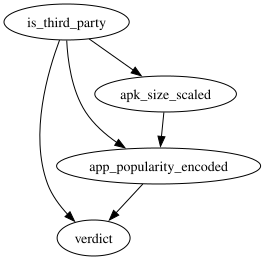

In [13]:
causal_graph = """
digraph {
    is_third_party -> verdict;
    app_popularity_encoded -> verdict;
    is_third_party -> app_popularity_encoded;
    is_third_party -> apk_size_scaled;
    apk_size_scaled -> app_popularity_encoded;
}
"""
graphviz.Source(causal_graph)

In [4]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    "<100", "100-500", "500-1k", "1k-5k", "5k-10k", "10k-50k",
    "50k-100k", "100k-500k", "500k-1M", "1M-5M", ">5M"
]
ord_map = {c: i for i, c in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("Rows:", len(df))
print("is_third_party counts:\n", df["is_third_party"].value_counts())
print("popularity counts:\n", df["app_popularity"].value_counts().reindex(download_order, fill_value=0))


Rows: 5612
is_third_party counts:
 is_third_party
1    5101
0     511
Name: count, dtype: int64
popularity counts:
 app_popularity
<100         626
100-500      604
500-1k       317
1k-5k        323
5k-10k       415
10k-50k      449
50k-100k     413
100k-500k    704
500k-1M      602
1M-5M        641
>5M          518
Name: count, dtype: int64


In [ ]:
Y = df["verdict"].values
T = df["app_popularity_encoded"].values  
W = df[["is_third_party"]].values        
X = df[["is_third_party"]].values 


# -----------------------------
# Fit DRLearner (multi-valued treatment)
# -----------------------------
dr = DRLearner(
    model_regression=RandomForestRegressor(n_estimators=10, min_samples_leaf=10, random_state=42),
    model_propensity=RandomForestClassifier(n_estimators=10, min_samples_leaf=10, random_state=42),
    model_final=RandomForestRegressor(n_estimators=10, min_samples_leaf=10, random_state=42),
    categories="auto",
    random_state=42
)

inference = BootstrapInference(n_bootstrap_samples=200, n_jobs=-1)

dr.fit(Y, T, X=X, W=W, inference=inference)
print("\nDRLearner fitted (treatment = app_popularity_encoded).")




DRLearner fitted (treatment = app_popularity_encoded).


In [6]:
baseline_label = "<100"
baseline_code = ord_map[baseline_label]

results = []
n = len(Y)

for k in sorted(np.unique(T)):
    if k == baseline_code:
        continue

    T0 = baseline_code
    T1 = int(k)

    tau = dr.effect(X=X, T0=T0, T1=T1)
    ate = float(np.mean(tau))

    ci_low, ci_high = dr.effect_interval(X=X, T0=T0, T1=T1, alpha=0.05)
    ate_low = float(np.mean(ci_low))
    ate_high = float(np.mean(ci_high))

    results.append({
        "bucket": download_order[int(k)],
        "bucket_code": int(k),
        "count": int((T == k).sum()),
        "ATE_vs_<100": ate,
        "CI_low": ate_low,
        "CI_high": ate_high
    })

res_df = pd.DataFrame(results).sort_values("bucket_code")

print("\n=== Popularity effect on precision (all alerts), vs <100 baseline ===")
print(res_df[["bucket", "count", "ATE_vs_<100", "CI_low", "CI_high"]])




=== Popularity effect on precision (all alerts), vs <100 baseline ===
      bucket  count  ATE_vs_<100    CI_low   CI_high
0    100-500    604     0.019231 -0.059647  0.090248
1     500-1k    317    -0.062765 -0.144155  0.025148
2      1k-5k    323     0.047775 -0.045058  0.120073
3     5k-10k    415     0.110831  0.031148  0.210881
4    10k-50k    449     0.084449 -0.013296  0.144052
5   50k-100k    413     0.045226 -0.031087  0.132750
6  100k-500k    704     0.068154 -0.007968  0.142149
7    500k-1M    602     0.123057  0.056393  0.196001
8      1M-5M    641     0.046329 -0.052266  0.118530
9        >5M    518     0.142864  0.061926  0.213053


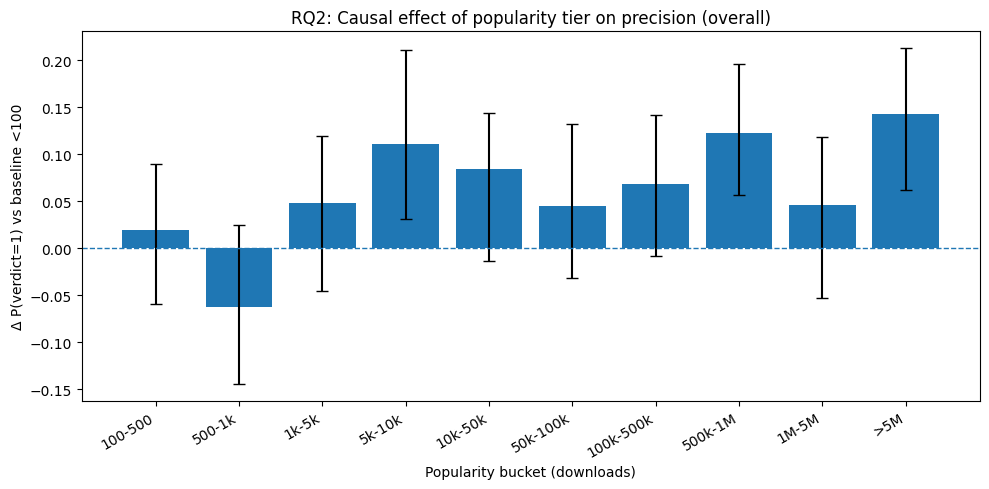

In [7]:
ci_low = res_df[["CI_low", "CI_high"]].min(axis=1).to_numpy()
ci_high = res_df[["CI_low", "CI_high"]].max(axis=1).to_numpy()
y = res_df["ATE_vs_<100"].to_numpy()

lower = np.clip(y - ci_low, 0, None)
upper = np.clip(ci_high - y, 0, None)
yerr = np.vstack([lower, upper])

x = np.arange(len(res_df))

plt.figure(figsize=(10, 5))
plt.bar(x, y, yerr=yerr, capsize=4)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, res_df["bucket"].tolist(), rotation=30, ha="right")
plt.ylabel("Δ P(verdict=1) vs baseline <100")
plt.xlabel("Popularity bucket (downloads)")
plt.title("RQ2: Causal effect of popularity tier on precision (overall)")
plt.tight_layout()
plt.show()



In [8]:
def cate_curve_for_alert_type(is_third_party_value: int):
    X_eval = np.full((n, 1), is_third_party_value, dtype=int)

    rows = []
    for k in sorted(np.unique(T)):
        if k == baseline_code:
            continue

        T0 = baseline_code
        T1 = int(k)

        tau = dr.effect(X=X_eval, T0=T0, T1=T1)
        cate = float(np.mean(tau))

        ci_l, ci_h = dr.effect_interval(X=X_eval, T0=T0, T1=T1, alpha=0.05)
        cate_low = float(np.mean(ci_l))
        cate_high = float(np.mean(ci_h))

        rows.append({
            "bucket": download_order[int(k)],
            "CATE": cate,
            "CI_low": cate_low,
            "CI_high": cate_high
        })
    return pd.DataFrame(rows)

cate_dev = cate_curve_for_alert_type(0).rename(columns={"CATE":"CATE_dev", "CI_low":"dev_low", "CI_high":"dev_high"})
cate_tp  = cate_curve_for_alert_type(1).rename(columns={"CATE":"CATE_third", "CI_low":"third_low", "CI_high":"third_high"})
cate_merged = cate_dev.merge(cate_tp, on="bucket")

print("\n=== CATE by alert type (vs <100 baseline) ===")
print(cate_merged)


=== CATE by alert type (vs <100 baseline) ===
      bucket  CATE_dev   dev_low  dev_high  CATE_third  third_low  third_high
0    100-500  0.142775 -0.107024  0.419628    0.006854  -0.054901    0.057251
1     500-1k  0.106121 -0.095892  0.336504   -0.079684  -0.148990   -0.006042
2      1k-5k  0.389933  0.209037  0.576742    0.013499  -0.070512    0.074325
3     5k-10k  0.050039 -0.125830  0.373564    0.116921   0.046874    0.194584
4    10k-50k  0.275393 -0.004314  0.454447    0.065320  -0.014196    0.112958
5   50k-100k  0.311130  0.197009  0.544654    0.018588  -0.053937    0.091486
6  100k-500k  0.168823 -0.066667  0.321980    0.058069  -0.002088    0.124134
7    500k-1M  0.523003  0.372681  0.666171    0.082992   0.024708    0.148901
8      1M-5M -0.005453 -0.482529  0.184343    0.051517  -0.009164    0.111937
9        >5M  0.458964  0.272495  0.668526    0.111198   0.040832    0.167425
